# Part A: Frontier-Based Exploration

## Environment Setup
Create a terminal in this directory (if using VSCode, the integrated terminal will suffice). To create a local virtual environment, run
```
python3 -m venv venv
```
This will create a separate python environment, named 'venv', where we can install the required dependencies. Activate the environment by running,
```
source ./venv/bin/activate
```
You should now see (venv) prepended to your terminal prompt. To install the required dependencies, run
```
pip install -r requirements.txt
```
Make sure to select this interpreter as the desired virtual environment for this jupyter notebook. If using vscode, it should default to this.

## Project Overview

This notebook guides you through implementing a frontier-based exploration algorithm for multi-robot systems. Watch the robots explore an unknown environment:

![Multi-Robot Exploration Demo](./a_heuristic_exploration/completed_project.gif)

You'll implement the core algorithms that enable this coordinated exploration behavior!

## Notebook Setup

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from typing import List, Tuple

# Import simulation components
from simulation.env import GridWorldEnv
from simulation.types import EnvConfig, CellState, Action
from simulation.render import render_ascii, render_matplotlib
from simulation.metrics import compute_coverage

# Import heuristic exploration components (students will implement these)
from a_heuristic_exploration.frontiers import extract_frontiers
from a_heuristic_exploration.information_gain import information_gain_count_unknown
from a_heuristic_exploration.planner_astar import astar_path
from a_heuristic_exploration.clustering import frontier_clusters_region_pca, region_growing_clusters
from a_heuristic_exploration.assignment import greedy_assignment
from a_heuristic_exploration.policy import HeuristicFrontierPolicy

from a_heuristic_exploration.visualization_utilities import visualize_map, create_exploration_gif

print("✓ All imports successful!")

✓ All imports successful!


## Step 0: Understanding the Environment

First, let's create a simple environment and understand the data structures.

In Part A, you will implement a **frontier-based exploration** algorithm that uses information theory and path planning to efficiently explore unknown environments.

### Key Concepts

A **frontier** is a free cell adjacent to at least one unknown cell. Frontiers represent the boundary between explored and unexplored space.

$$
\mathcal{F} = \{ c \mid c = \text{Free}, \exists c' \in \mathcal{N}(c), c' = \text{Unknown} \}
$$

### What You'll Implement

You will complete functions in the `a_heuristic_exploration/` module:

1. **Frontier Detection** (`frontiers.py`)
2. **Path Planning** (`planner_astar.py`) - A* algorithm
3. **Information Gain** (`information_gain.py`) - Scoring frontier value
4. **Clustering** (`clustering.py`) - Grouping frontiers for multi-robot assignment
5. **Task Assignment** (`assignment.py`) - Assigning robots to frontier clusters

This notebook will guide you through each component with testing and visualization.

In [3]:
# Create a small test environment
config = EnvConfig(
    width=40,
    height=40,
    num_robots=3,
    max_steps=200,
    sensor_radius=3,
    obstacle_prob=0.15,
    seed=42
)

env = GridWorldEnv(config)
obs = env.reset()

print(f"Environment: {config.width}x{config.height}")
print(f"Number of robots: {config.num_robots}")
print(f"Sensor radius: {config.sensor_radius}")
print(f"\nRobot positions: {obs.robot_positions}")
print(f"Fused map shape: {obs.fused_map.shape}")
print(f"\nInitial coverage: {compute_coverage(obs.fused_map):.2%}")

Environment: 40x40
Number of robots: 3
Sensor radius: 3

Robot positions: [(17, 25), (34, 23), (13, 14)]
Fused map shape: (40, 40)

Initial coverage: 9.19%


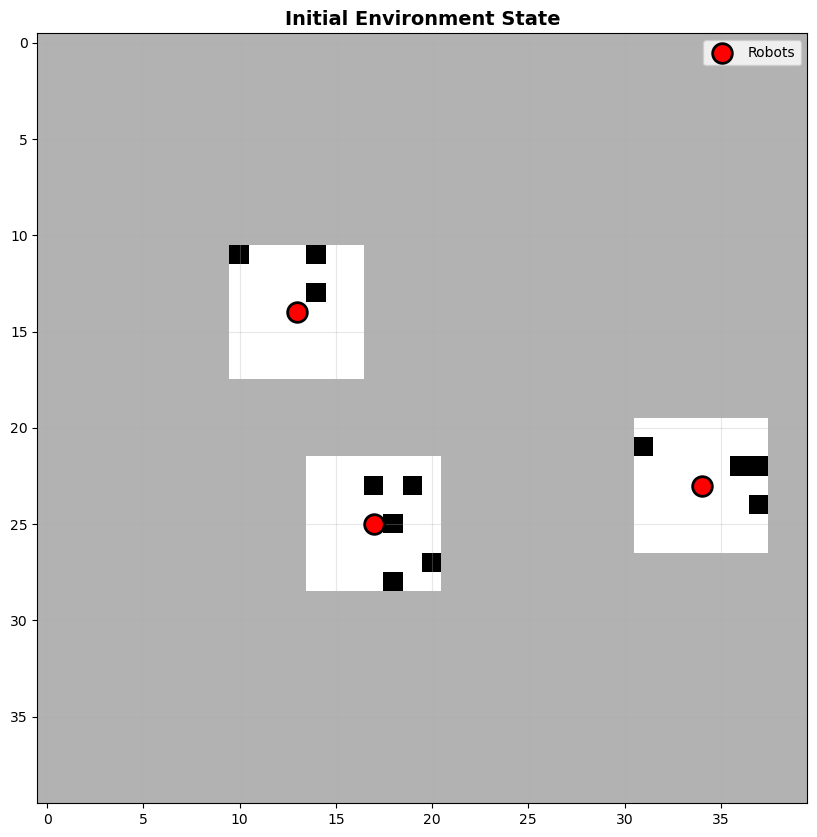

In [4]:
# Visualize initial state
fig, ax = visualize_map(obs.fused_map, obs.robot_positions, title="Initial Environment State")
plt.show()

## Step 1: Frontier Detection

### 🎯 Your Task

Open `a_heuristic_exploration/frontiers.py` and implement the `extract_frontiers()` function.

**Requirements:**
- A frontier is a **FREE** cell that is adjacent (4-neighborhood) to at least one **UNKNOWN** cell
- Return a list of `(x, y)` coordinates
- The map is indexed as `fused_map[y, x]`

**Algorithm Hint:**
1. Create boolean masks for FREE and UNKNOWN cells
2. For each FREE cell, check if any 4-connected neighbor is UNKNOWN
3. Use numpy operations for efficiency (avoid nested loops if possible)

Once implemented, run the cells below to test your implementation.

### Cell States

The map uses integer encoding:
- **0 (FREE)**: Traversable empty space
- **1 (OCCUPIED)**: Obstacle/wall
- **2 (UNKNOWN)**: Unexplored area

The `fused_map` is shared among all robots and updated as they explore.
Agents also maintain an 'individual map' with their own observations. 
We will explore the impact of time- and event-based map sharing on algorithm performance.

In [5]:
# Test frontier extraction
frontiers = extract_frontiers(env.get_fused_map())

if not frontiers:
    print("⚠ No frontiers detected - check your implementation!")
    assert False

# Verify frontier properties
print(f"Number of frontiers detected: {len(frontiers)}")
print(f"Sample frontiers (first 10): {frontiers[:10]}")

# Check that all frontiers are FREE cells
for fx, fy in frontiers[:20]:  # Check first 20
    assert obs.fused_map[fy, fx] == int(CellState.FREE), \
        f"Frontier ({fx}, {fy}) is not FREE!"
print("✓ All sampled frontiers are FREE cells")

# Check that they're adjacent to UNKNOWN
count_adjacent = 0
for fx, fy in frontiers[:20]:
    adjacent_unknown = False
    for dx, dy in [(0, 1), (0, -1), (1, 0), (-1, 0)]:
        nx, ny = fx + dx, fy + dy
        if 0 <= nx < config.width and 0 <= ny < config.height:
            if obs.fused_map[ny, nx] == int(CellState.UNKNOWN):
                adjacent_unknown = True
                break
    if adjacent_unknown:
        count_adjacent += 1

print(f"✓ {count_adjacent}/20 sampled frontiers are adjacent to UNKNOWN cells")

Number of frontiers detected: 65
Sample frontiers (first 10): [(11, 11), (12, 11), (13, 11), (15, 11), (16, 11), (10, 12), (16, 12), (10, 13), (16, 13), (10, 14)]
✓ All sampled frontiers are FREE cells
✓ 20/20 sampled frontiers are adjacent to UNKNOWN cells


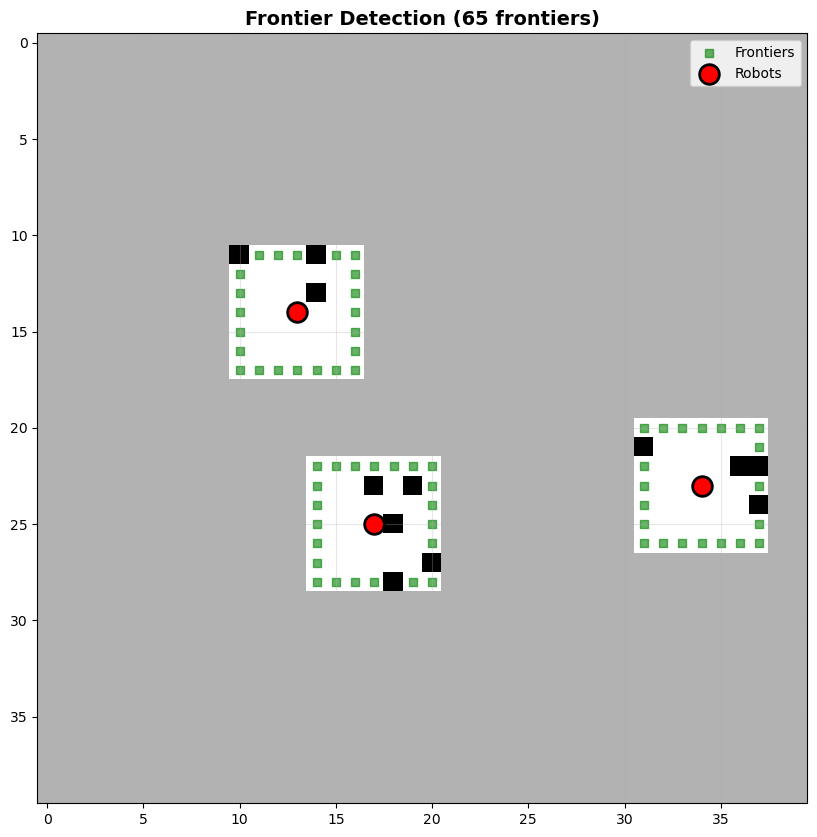

In [6]:
# Visualize frontiers
visualize_map(obs.fused_map, obs.robot_positions, frontiers, 
              title=f"Frontier Detection ({len(frontiers)} frontiers)")
plt.show()

The environment automatically maintains a ```fused_map``` which reflects the 'union' of all information gained by the agents in the system. This can be accessed with ```env.get_fused_map()```.

In addition to the fused map, each agent maintains a ```robot_map``` which reflects the information known to that agent. These maps can be accessed with ```env.get_robot_maps()```.

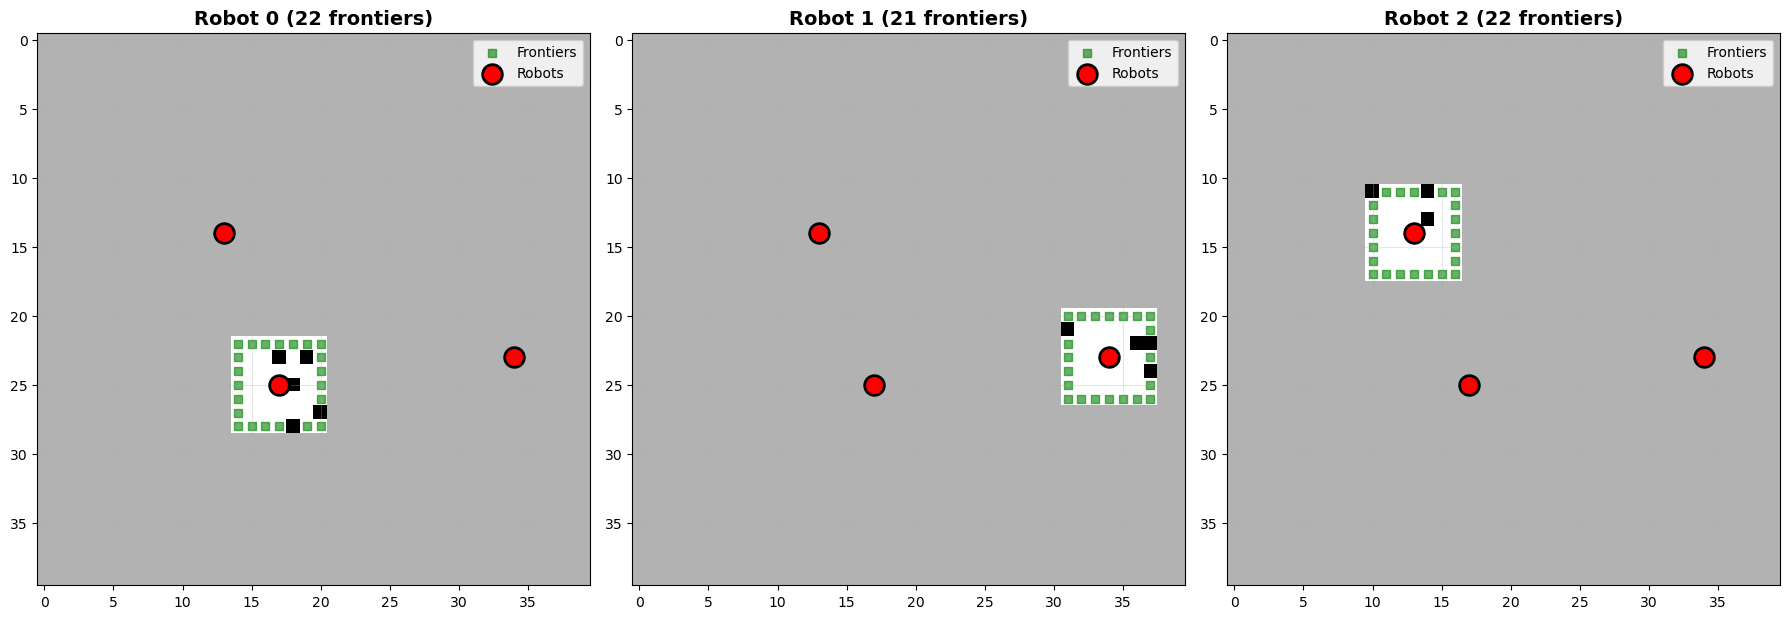

In [7]:
robot_frontiers = [extract_frontiers(robot_map) for robot_map in env.get_robot_maps()]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for i, (frontier_set, robot_map) in enumerate(zip(robot_frontiers, env.get_robot_maps())):
    visualize_map(robot_map, obs.robot_positions, frontier_set,
                  title=f"Robot {i} ({len(frontier_set)} frontiers)",
                  ax=axes[i])
plt.tight_layout()
plt.show()


The ```env.share_knowledge()``` function simulates a knowledge-sharing event between a list of specified agents. The result is that all the specified agent's private maps become the union of all their maps.

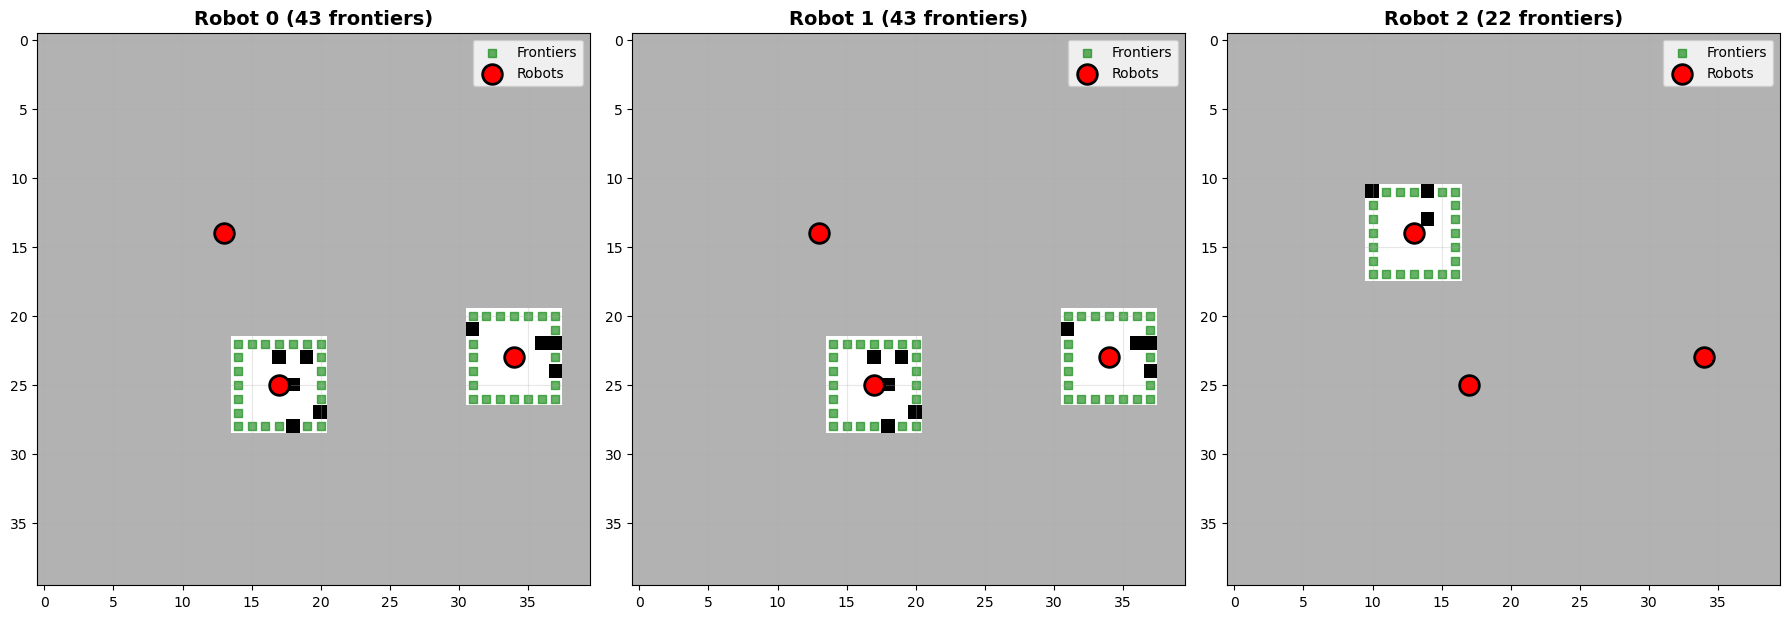

In [8]:
# Simulate a knowledge sharing event between agents 0 and 1
env.share_knowledge([0, 1])

robot_frontiers = [extract_frontiers(robot_map) for robot_map in env.get_robot_maps()]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for i, (frontier_set, robot_map) in enumerate(zip(robot_frontiers, env.get_robot_maps())):
    visualize_map(robot_map, obs.robot_positions, frontier_set,
                  title=f"Robot {i} ({len(frontier_set)} frontiers)",
                  ax=axes[i])
plt.tight_layout()
plt.show()

## Step 2: Path Planning with A*

### 🎯 Your Task

Open `a_heuristic_exploration/planner_astar.py` and implement the `astar_path()` function.

**Requirements:**
- Implement A* shortest path algorithm
- Use Manhattan distance as the heuristic: $h(a, b) = |a_x - b_x| + |a_y - b_y|$
- Only traverse **FREE** cells (treat UNKNOWN as blocked for safety)
- Return a list of `(x, y)` coordinates from start to goal (inclusive), or `None` if no path exists

**Algorithm Reminder:**
1. Maintain an open set (priority queue) sorted by $f(n) = g(n) + h(n)$
2. $g(n)$ = cost from start to current node
3. $h(n)$ = heuristic estimate from current to goal
4. Expand lowest-cost nodes first
5. Track visited nodes to avoid cycles

Once implemented, test below.

In [9]:
# Test A* path planning
robot_pos = obs.robot_positions[0]

if not frontiers:
    print("⚠ No frontiers to test path planning")
    assert False

# Pick a frontier to navigate to
target = frontiers[len(frontiers) // 2 + 1]  # Pick a frontier

path = astar_path(obs.fused_map, robot_pos, target)

if path:
    print(f"✓ Path found from {robot_pos} to {target}")
    print(f"  Path length: {len(path)} steps")
    print(f"  Path preview: {path[:5]} ... {path[-3:]}")
    
    # Verify path properties
    assert path[0] == robot_pos, "Path should start at robot position"
    assert path[-1] == target, "Path should end at target"
    
    # Check all steps are valid (1-cell Manhattan distance)
    for i in range(len(path) - 1):
        x1, y1 = path[i]
        x2, y2 = path[i + 1]
        dist = abs(x2 - x1) + abs(y2 - y1)
        assert dist == 1, f"Invalid step from {path[i]} to {path[i+1]}"
    
    print("✓ Path validation passed!")
else:
    print(f"⚠ No path found to {target} - this may be valid if unreachable")

✓ Path found from (17, 25) to (17, 22)
  Path length: 6 steps
  Path preview: [(17, 25), (17, 24), (16, 24), (16, 23), (16, 22)] ... [(16, 23), (16, 22), (17, 22)]
✓ Path validation passed!


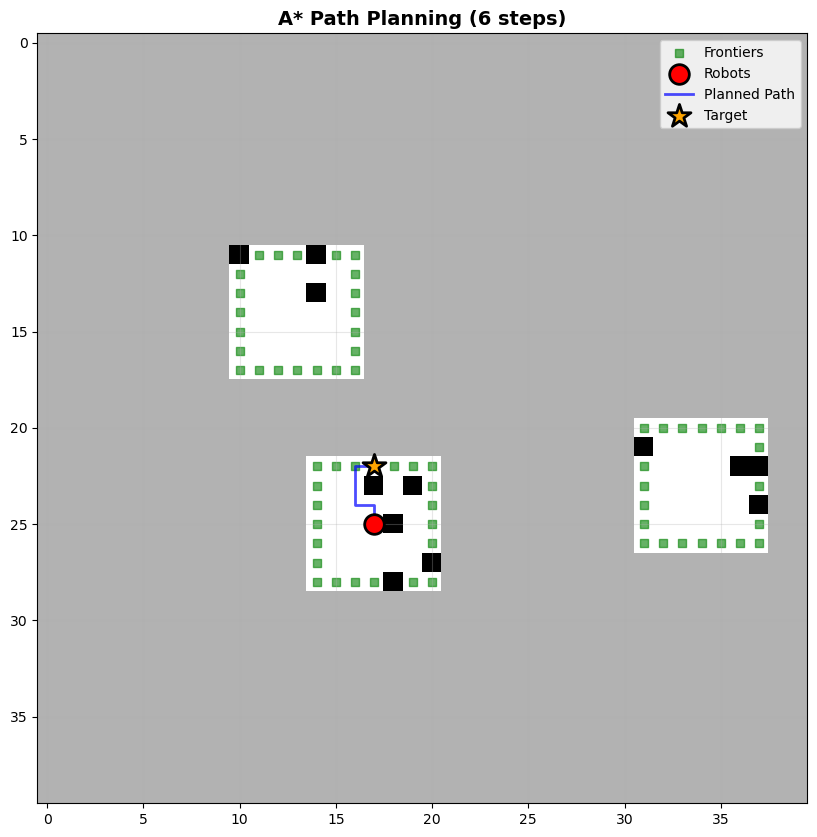

In [10]:
# Visualize the path
if frontiers and path:
    fig, ax = visualize_map(obs.fused_map, [robot_pos], frontiers, 
                            title=f"A* Path Planning ({len(path)} steps)")
    
    # Draw the path
    if len(path) > 1:
        path_x, path_y = zip(*path)
        ax.plot(path_x, path_y, 'b-', linewidth=2, alpha=0.7, label='Planned Path')
        ax.scatter([target[0]], [target[1]], c='orange', s=300, marker='*', 
                   edgecolors='black', linewidths=2, label='Target', zorder=6)
    
    ax.legend(loc='upper right')
    plt.show()

## Step 3: Information Gain

### 🎯 Your Task

Open `a_heuristic_exploration/information_gain.py` and implement the `information_gain_count_unknown()` function.

**Requirements:**
- Count the number of **UNKNOWN** cells within a radius-$R$ box around a target location
- Use Chebyshev distance (max of $|x_1 - x_2|$ and $|y_1 - y_2|$) for the neighborhood
- This represents how much new information we expect to gain by moving to that frontier

**Formula:**
$$
\text{IG}(t) = |\{ c \in \mathcal{B}(t, R) : c = \text{UNKNOWN} \}|
$$

where $\mathcal{B}(t, R)$ is a box of radius $R$ around target $t$.

In [11]:
# Test information gain calculation
ig_radius = 4

if not frontiers:
    print("⚠ No frontiers to calculate information gain")
    assert False

# Calculate IG for several frontiers
frontier_sample = frontiers[:min(10, len(frontiers))]
ig_values = []

for f in frontier_sample:
    ig = information_gain_count_unknown(obs.fused_map, f, ig_radius)
    ig_values.append((f, ig))

# Sort by IG (highest first)
ig_values.sort(key=lambda x: x[1], reverse=True)

print(f"Information Gain for sample frontiers (radius={ig_radius}):\n")
for i, (frontier, ig) in enumerate(ig_values[:5]):
    print(f"  {i+1}. Frontier {frontier}: IG = {ig}")

print(f"\n✓ Best frontier has IG = {ig_values[0][1]}")
print(f"✓ Worst frontier has IG = {ig_values[-1][1]}")

# Verify IG is non-negative
assert all(ig >= 0 for _, ig in ig_values), "IG should be non-negative"
print("✓ All IG values are non-negative")

Information Gain for sample frontiers (radius=4):

  1. Frontier (16, 11): IG = 56
  2. Frontier (11, 11): IG = 51
  3. Frontier (15, 11): IG = 51
  4. Frontier (10, 12): IG = 51
  5. Frontier (16, 12): IG = 51

✓ Best frontier has IG = 56
✓ Worst frontier has IG = 46
✓ All IG values are non-negative


## Step 4: Single-Agent Greedy Exploration


Now let's combine all components to create a simple greedy exploration strategy for **one robot**:

1. Detect all frontiers
2. Calculate information gain for each frontier
3. Compute path cost (length) to each frontier
4. Select frontier with highest utility: $U = \alpha \cdot \text{IG} - \beta \cdot \text{Cost}$
5. Execute the path

Let's implement this policy in a simple function.

In [12]:
def greedy_single_agent_policy(map, robot_pos, alpha=1.0, beta=0.1, ig_radius=4):
    """
    Simple greedy policy for single-agent exploration.
    
    Returns:
        Action to take
    """
    # Step 1: Extract frontiers
    frontiers = extract_frontiers(map)
    
    if not frontiers:
        return Action.STAY  # No frontiers left
    
    # Step 2 & 3: Calculate utility for each frontier
    best_utility = float('-inf')
    best_frontier = None
    best_path = None
    
    for frontier in frontiers:
        # Information gain
        ig = information_gain_count_unknown(map, frontier, ig_radius)
        
        # Path cost
        path = astar_path(map, robot_pos, frontier)
        if path is None:
            continue  # Unreachable
        
        cost = len(path)
        
        # Utility function
        utility = alpha * ig - beta * cost
        
        if utility > best_utility:
            best_utility = utility
            best_frontier = frontier
            best_path = path
    
    # Step 4: Execute first action along best path
    if best_path and len(best_path) >= 2:
        next_pos = best_path[1]
        dx = next_pos[0] - robot_pos[0]
        dy = next_pos[1] - robot_pos[1]
        
        if dx == 1:
            return Action.RIGHT
        elif dx == -1:
            return Action.LEFT
        elif dy == 1:
            return Action.DOWN
        elif dy == -1:
            return Action.UP
    
    return Action.STAY

print("✓ Greedy single-agent policy defined")

✓ Greedy single-agent policy defined


In [13]:
# Run the greedy exploration for a single robot
config_single = EnvConfig(
    width=40,
    height=40,
    num_robots=1,
    max_steps=500,
    sensor_radius=3,
    obstacle_prob=0.15,
    seed=123
)

env_single = GridWorldEnv(config_single)
obs = env_single.reset()

coverage_history = [compute_coverage(obs.fused_map)]
step_history = [0]

print("Running single-agent greedy exploration...")
print(f"Initial coverage: {coverage_history[0]:.2%}\n")

# Run for several steps
for step in range(1, 500):
    action = greedy_single_agent_policy(obs.fused_map, obs.robot_positions[0], alpha=0.0001, beta=0.05)
    result = env_single.step([action])
    obs = env_single.observe()
    
    coverage_history.append(result.coverage)
    step_history.append(step)
    
    if step % 30 == 0:
        print(f"Step {step:3d}: Coverage = {result.coverage:.2%}")
    
    if result.done or result.coverage >= 0.99:
        print(f"\nExploration completed at step {step}")
        print(f"Final coverage: {result.coverage:.2%}")
        break

print("\n✓ Greedy exploration complete")

Running single-agent greedy exploration...
Initial coverage: 2.62%

Step  30: Coverage = 15.69%
Step  60: Coverage = 28.44%
Step  90: Coverage = 37.81%
Step 120: Coverage = 44.69%
Step 150: Coverage = 52.62%
Step 180: Coverage = 65.75%
Step 210: Coverage = 78.75%
Step 240: Coverage = 84.50%
Step 270: Coverage = 89.88%
Step 300: Coverage = 94.50%
Step 330: Coverage = 95.00%
Step 360: Coverage = 95.56%
Step 390: Coverage = 96.69%

Exploration completed at step 402
Final coverage: 99.19%

✓ Greedy exploration complete


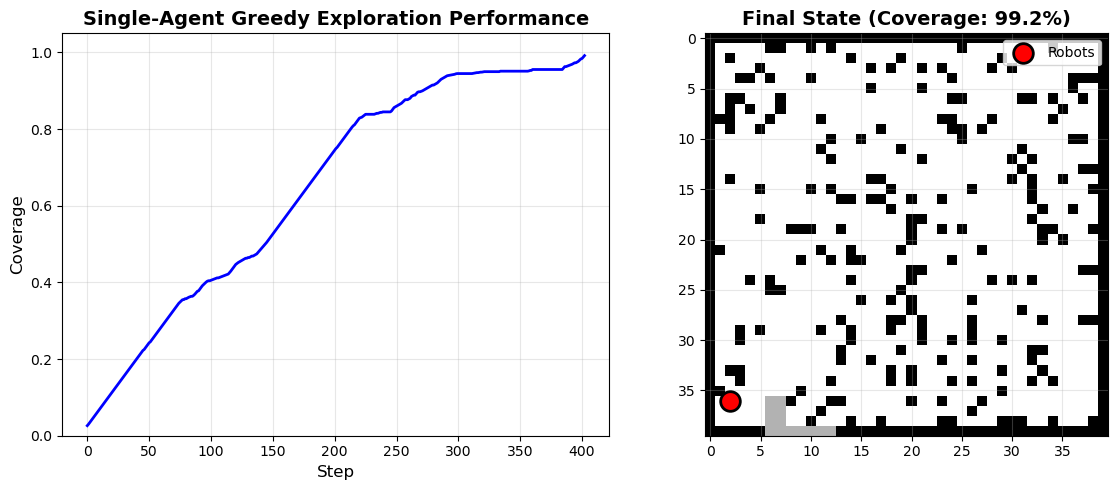

In [14]:
# Plot coverage over time
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(step_history, coverage_history, 'b-', linewidth=2)
ax1.set_xlabel('Step', fontsize=12)
ax1.set_ylabel('Coverage', fontsize=12)
ax1.set_title('Single-Agent Greedy Exploration Performance', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.set_ylim([0, 1.05])

visualize_map(obs.fused_map, obs.robot_positions,
              title=f"Final State (Coverage: {coverage_history[-1]:.1%})",
              ax=ax2)

plt.tight_layout()
plt.savefig("q1_single_agent_greedy_exploration.png")
plt.show()


### Single-Agent Policy on Multiple Agents
Lets now evaluate the performance of the single-agent greedy policy deployed on multiple agents with only local map knowledge.

In [15]:
# Run the greedy exploration for multiple robots
config_multi = EnvConfig(
    width=40,
    height=40,
    num_robots=3,
    max_steps=500,
    sensor_radius=3,
    obstacle_prob=0.15,
    seed=123
)

env_multi = GridWorldEnv(config_multi)
obs = env_multi.reset()

coverage_history = [compute_coverage(obs.fused_map)]
step_history = [0]

print("Running multi-agent greedy exploration...")
print(f"Initial coverage: {coverage_history[0]:.2%}\n")

# Run for several steps
for step in range(1, 500):
    observations = env_multi.observe_all()
    robot_states = [(pos.x, pos.y) for pos in env_multi.get_robot_states()]

    assert len(observations) == config_multi.num_robots, "Should have one observation per robot"

    actions = [greedy_single_agent_policy(local_obs.robot_map, pos, alpha=0.0001, beta=0.05) for local_obs, pos in zip(observations, robot_states)]

    result = env_multi.step(actions)
    
    coverage_history.append(result.coverage)
    step_history.append(step)
    
    if step % 30 == 0:
        print(f"Step {step:3d}: Coverage = {result.coverage:.2%}")
    
    if result.done or result.coverage >= 0.99:
        print(f"\nExploration completed at step {step}")
        print(f"Final coverage: {result.coverage:.2%}")
        break

print("\n✓ Greedy exploration complete")

# Store for later comparisions
multi_agent_coverage_history = coverage_history
multi_agent_step_history = step_history

Running multi-agent greedy exploration...
Initial coverage: 8.75%

Step  30: Coverage = 35.94%
Step  60: Coverage = 58.81%
Step  90: Coverage = 66.06%
Step 120: Coverage = 72.62%
Step 150: Coverage = 79.75%
Step 180: Coverage = 89.69%
Step 210: Coverage = 93.44%
Step 240: Coverage = 95.62%
Step 270: Coverage = 96.62%
Step 300: Coverage = 96.62%
Step 330: Coverage = 96.62%
Step 360: Coverage = 97.56%

Exploration completed at step 366
Final coverage: 99.06%

✓ Greedy exploration complete


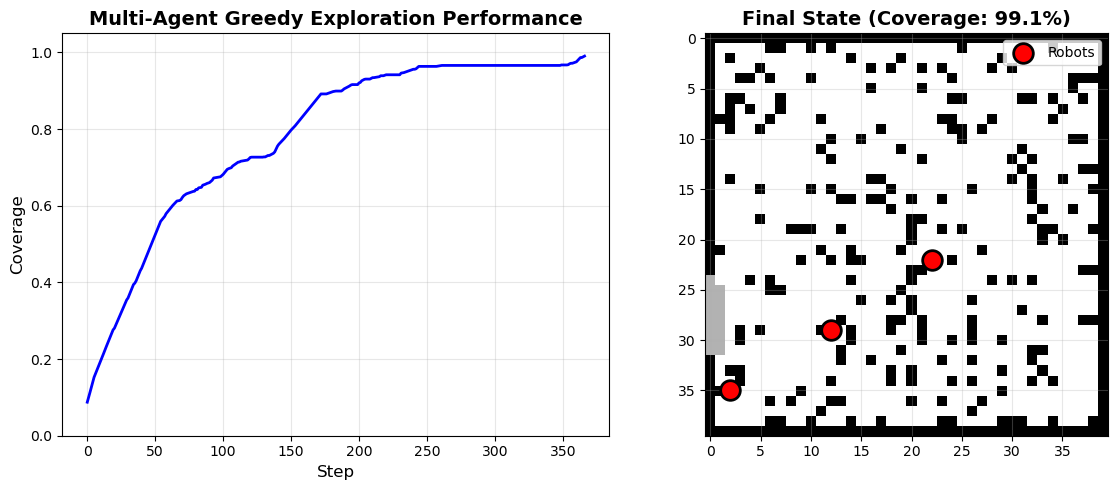

In [16]:
# Plot coverage over time
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(step_history, coverage_history, 'b-', linewidth=2)
ax1.set_xlabel('Step', fontsize=12)
ax1.set_ylabel('Coverage', fontsize=12)
ax1.set_title('Multi-Agent Greedy Exploration Performance', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.set_ylim([0, 1.05])

states = [(pos.x, pos.y) for pos in env_multi.get_robot_states()]

visualize_map(env_multi.get_fused_map(), states,
              title=f"Final State (Coverage: {coverage_history[-1]:.1%})",
              ax=ax2)

plt.tight_layout()
plt.savefig("q2_multi_agent_greedy_exploration.png")
plt.show()

### Evaluation with Different Information Sharing Conditions
In the above implementation, each agent explored the environment using only their local map, until the combined 'fused map' reached the desired coverage level. Now, we explore the effect of different 'information sharing' conditions on the performance of the algorithm.

In [17]:
# First, evaluate 'time-based' information sharing, where agents all synchronize their maps ever N steps

N = 20 # Synchronize every 20 steps

# Run the greedy exploration for multiple robots
config_multi = EnvConfig(
    width=40,
    height=40,
    num_robots=3,
    max_steps=500,
    sensor_radius=3,
    obstacle_prob=0.15,
    seed=123
)

env_multi = GridWorldEnv(config_multi)
obs = env_multi.reset()

coverage_history = [compute_coverage(obs.fused_map)]
step_history = [0]

print("Running multi-agent greedy exploration...")
print(f"Initial coverage: {coverage_history[0]:.2%}\n")

# Run for several steps
for step in range(1, 500):
    observations = env_multi.observe_all()
    robot_states = [(pos.x, pos.y) for pos in env_multi.get_robot_states()]

    actions = [greedy_single_agent_policy(local_obs.robot_map, pos, alpha=0.0001, beta=0.05) for local_obs, pos in zip(observations, robot_states)]

    result = env_multi.step(actions)
    
    coverage_history.append(result.coverage)
    step_history.append(step)

    if step % N == 0:
        # raise NotImplementedError("Implement time-based information sharing and remove this error")
        # hint: use the env_multi.share_knowledge() function to share information among all robots
        env_multi.share_knowledge(list(range(config_multi.num_robots)))
    
    if step % 30 == 0:
        print(f"Step {step:3d}: Coverage = {result.coverage:.2%}")
    
    if result.done or result.coverage >= 0.99:
        print(f"\nExploration completed at step {step}")
        print(f"Final coverage: {result.coverage:.2%}")
        break

print("\n✓ Exploration complete")

# Store for later comparisions
multi_agent_time_based_coverage_history = coverage_history
multi_agent_time_based_step_history = step_history

Running multi-agent greedy exploration...
Initial coverage: 8.75%

Step  30: Coverage = 39.69%
Step  60: Coverage = 66.56%
Step  90: Coverage = 87.88%
Step 120: Coverage = 96.88%

Exploration completed at step 142
Final coverage: 99.00%

✓ Exploration complete


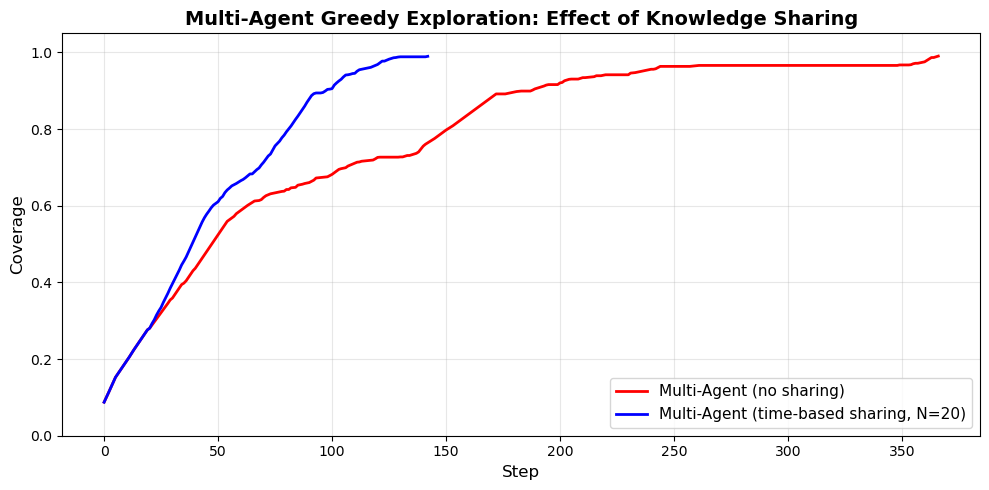

In [18]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(multi_agent_step_history, multi_agent_coverage_history, 'r-', linewidth=2, label='Multi-Agent (no sharing)')
ax.plot(step_history, coverage_history, 'b-', linewidth=2, label=f'Multi-Agent (time-based sharing, N={N})')

ax.set_xlabel('Step', fontsize=12)
ax.set_ylabel('Coverage', fontsize=12)
ax.set_title('Multi-Agent Greedy Exploration: Effect of Knowledge Sharing', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 1.05])
plt.tight_layout()
plt.savefig("q3_multi_agent_sharing_comparison.png")
plt.show()


Play around with varying the $N$ parameter to observe the effect on convergence rate.

## Step 5: Multi-Agent Coordination


For multiple robots, we need additional components:

### 🎯 Your Tasks

#### 5a. Frontier Clustering (`clustering.py`)

You'll implement three functions:

1. **`region_growing_clusters()`**
   - Groups spatially adjacent frontiers into clusters
   - Uses 8-connectivity

2. **`cluster_representative_point()`**
   - Selects a 'representative point' for a cluster
   - Used as the point agents navigate to

3. **`split_cluster_pca_recursive()`**
   - Recursively splits large clusters using PCA
   - Ensures we have enough clusters for all robots, and also shrinks clusters so that they are sized correctly for a single robot

This is inspired by the implementation in 
> Zhou, Boyu, Hao Xu, and Shaojie Shen. “RACER: Rapid Collaborative Exploration With a Decentralized Multi-UAV System.” IEEE Transactions on Robotics 39, no. 3 (2023): 1816–35. https://doi.org/10.1109/TRO.2023.3236945.

First, simulate the single agent greedy policy executing for some time to create a baseline map.

In [19]:
# Create a small test environment
config_single = EnvConfig(
    width=40,
    height=40,
    num_robots=1,
    max_steps=500,
    sensor_radius=3,
    obstacle_prob=0.15,
    seed=123
)

env_single = GridWorldEnv(config_single)
obs = env_single.reset()

coverage_history = [compute_coverage(obs.fused_map)]
step_history = [0]

# Run for several steps -- Terminate at only 75% coverage for testing
for step in range(1, 500):
    map = env_single.get_fused_map()
    pos = env_single.get_robot_states()[0]
    pos = (pos.x, pos.y)
    action = greedy_single_agent_policy(map, pos,  alpha=0.0001, beta=0.05)
    result = env_single.step([action])
    obs = env_single.observe()
    
    coverage_history.append(result.coverage)
    step_history.append(step)
    
    if step % 30 == 0:
        print(f"Step {step:3d}: Coverage = {result.coverage:.2%}")
    
    if result.done or result.coverage >= 0.75:
        print(f"\nExploration completed at step {step}")
        print(f"Final coverage: {result.coverage:.2%}")
        break



Step  30: Coverage = 15.69%
Step  60: Coverage = 28.44%
Step  90: Coverage = 37.81%
Step 120: Coverage = 44.69%
Step 150: Coverage = 52.62%
Step 180: Coverage = 65.75%

Exploration completed at step 202
Final coverage: 75.25%


Now evaluate the implemented functions on the baseline map. We should see that the PCA splitting 'breaks' large frontier clusters into smaller ones, more manageable for exploration with a single agent.

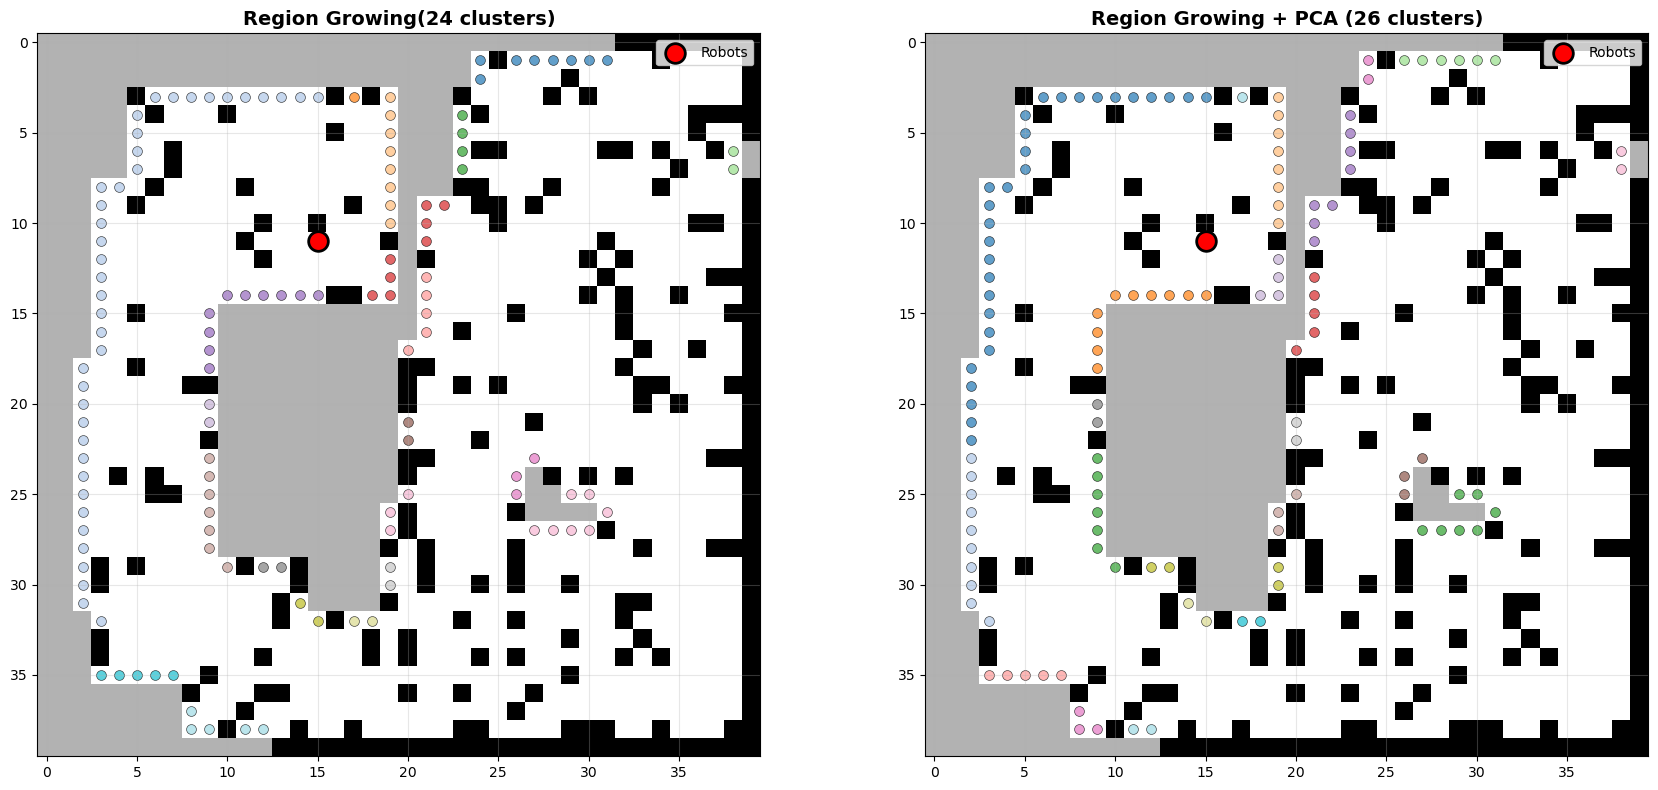

In [20]:
# Test frontier clustering
frontiers = extract_frontiers(obs.fused_map)

# Cluster the frontiers
grown_clusters = region_growing_clusters(frontiers)
split_clusters = frontier_clusters_region_pca(frontiers)

# Create figure with subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# Visualize clusters with different colors - Region Growing
visualize_map(obs.fused_map, obs.robot_positions, 
              title=f"Region Growing({len(grown_clusters)} clusters)",
              ax=ax1)

# Color each cluster differently
colors = plt.cm.tab20(np.linspace(0, 1, len(grown_clusters)))
for i, cluster in enumerate(grown_clusters):  
    if cluster:
        cx, cy = zip(*cluster)
        ax1.scatter(cx, cy, c=[colors[i]], s=50, alpha=0.7, edgecolors='black', linewidths=0.5)

# Visualize clusters with different colors - PCA
visualize_map(obs.fused_map, obs.robot_positions, 
              title=f"Region Growing + PCA ({len(split_clusters)} clusters)",
              ax=ax2)

# Color each cluster differently
colors = plt.cm.tab20(np.linspace(0, 1, len(split_clusters)))
for i, cluster in enumerate(split_clusters):  
    if cluster:
        cx, cy = zip(*cluster)
        ax2.scatter(cx, cy, c=[colors[i]], s=50, alpha=0.7, edgecolors='black', linewidths=0.5)

plt.tight_layout()
plt.savefig("q4_frontier_clustering.png")
plt.show()

#### 5b. Task Assignment (`assignment.py`)

- Given a utility matrix `utilities[i][j]` (robot i → target j)

Implement **`greedy_assignment()`**:
- Assign each robot to a different target using a greedy approach: repeatedly pick the highest-utility unassigned pair

Compare to the performance of the **`hungarian_assignment()`** algorithm.

In [21]:
# Test task assignment
from a_heuristic_exploration.assignment import hungarian_assignment

num_robots = 30
num_targets = 60 

# Create a sample utility matrix
utilities = np.random.rand(num_robots, num_targets) * 50  # Random utilities for testing

# Run greedy assignment
greedy_assignments = greedy_assignment(utilities)
optimal_assignments = hungarian_assignment(utilities)


# Print Results (commented out to reduce output, but you can uncomment to see the full assignments, which can be quite verbose with 30 robots and 60 targets)

# print(f"\nGreedy assignment result:")
# for robot_id, target_id in sorted(greedy_assignments.robot_to_target.items()):
#     utility = utilities[robot_id][target_id]
#     print(f"  Robot {robot_id} → Target {target_id} (utility: {utility})")

# print(f"\nOptimal assignment result:")
# for robot_id, target_id in sorted(optimal_assignments.robot_to_target.items()):
#     utility = utilities[robot_id][target_id]
#     print(f"  Robot {robot_id} → Target {target_id} (utility: {utility})")

greedy_total_utility = sum(utilities[i][j] for i, j in greedy_assignments.robot_to_target.items())
print(f"\nTotal utility (Greedy): {greedy_total_utility}")

optimal_total_utility = sum(utilities[i][j] for i, j in optimal_assignments.robot_to_target.items())
print(f"Total utility (Optimal): {optimal_total_utility}")
print("✓ Task assignment complete")



Total utility (Greedy): 1464.5353212759621
Total utility (Optimal): 1473.580309667286
✓ Task assignment complete


You should see that the Hungarian assignment method always performs as well or better than the greedy policy! But in general, the two performed very similarly.

## Step 6: Full Multi-Agent Exploration


Now let's test the complete multi-agent heuristic policy implemented in `HeuristicFrontierPolicy`.

This policy orchestrates all components:
1. Extracts frontiers periodically
2. Clusters frontiers into groups
3. Computes utility for each robot-target pair
4. Assigns robots to targets
5. Plans paths and executes actions

First, lets evaluate the multi agent policy on a small environment, and compare it to the performance of the greedy single agent policy applied to multiple agents, like with above.

In [22]:
# Run multi-agent heuristic exploration
from a_heuristic_exploration.policy import HeuristicConfig

config_multi = EnvConfig(
    width=40,
    height=40,
    num_robots=4,
    max_steps=500,
    sensor_radius=3,
    obstacle_prob=0.15,
    seed=123
)

env_multi = GridWorldEnv(config_multi)
obs = env_multi.reset()

# Create the heuristic policy
greedy_heuristic_config = HeuristicConfig(
    alpha=0.001,
    beta=1.0,
    ig_radius=4,
    replanning_period=10,
    assignment_method='greedy'
)
greedy_policy = HeuristicFrontierPolicy(config=greedy_heuristic_config)
greedy_policy.reset(obs)

coverage_history_multi = [compute_coverage(obs.fused_map)]
step_history_multi = [0]

print(f"Running multi-agent heuristic exploration with {config_multi.num_robots} robots...")
print(f"Initial coverage: {coverage_history_multi[0]:.2%}\n")

# Run exploration
for step in range(1, config_multi.max_steps):
    actions = greedy_policy.act(obs)
    result = env_multi.step(actions)
    obs = env_multi.observe()
    
    coverage_history_multi.append(result.coverage)
    step_history_multi.append(step)
    
    if step % 50 == 0:
        print(f"Step {step:3d}: Coverage = {result.coverage:.2%}")
    
    if result.done or result.coverage >= 0.99:
        print(f"\nExploration completed at step {step}")
        print(f"Final coverage: {result.coverage:.2%}")
        break

print("\n✓ Multi-agent exploration complete")

greedy_assignment_coverage_history = coverage_history_multi
greedy_assignment_step_history = step_history_multi

Running multi-agent heuristic exploration with 4 robots...
Initial coverage: 11.81%

Step  50: Coverage = 68.81%
Step 100: Coverage = 92.88%

Exploration completed at step 129
Final coverage: 99.12%

✓ Multi-agent exploration complete


In [23]:
# Run multi-agent heuristic exploration
from a_heuristic_exploration.policy import HeuristicConfig

config_multi = EnvConfig(
    width=40,
    height=40,
    num_robots=4,
    max_steps=500,
    sensor_radius=3,
    obstacle_prob=0.15,
    seed=123
)

env_multi = GridWorldEnv(config_multi)
obs = env_multi.reset()

# Create the heuristic policy
greedy_heuristic_config = HeuristicConfig(
    alpha=0.5,
    beta=0.67,
    ig_radius=4,
    replanning_period=4,
    assignment_method='hungarian'
)
greedy_policy = HeuristicFrontierPolicy(config=greedy_heuristic_config)
greedy_policy.reset(obs)

coverage_history_multi = [compute_coverage(obs.fused_map)]
step_history_multi = [0]

print(f"Running multi-agent heuristic exploration with {config_multi.num_robots} robots...")
print(f"Initial coverage: {coverage_history_multi[0]:.2%}\n")

# Run exploration
for step in range(1, config_multi.max_steps):
    actions = greedy_policy.act(obs)
    result = env_multi.step(actions)
    obs = env_multi.observe()
    
    coverage_history_multi.append(result.coverage)
    step_history_multi.append(step)
    
    if step % 50 == 0:
        print(f"Step {step:3d}: Coverage = {result.coverage:.2%}")
    
    if result.done or result.coverage >= 0.99:
        print(f"\nExploration completed at step {step}")
        print(f"Final coverage: {result.coverage:.2%}")
        break

print("\n✓ Multi-agent exploration complete")

hungarian_assignment_coverage_history = coverage_history_multi
hungarian_assignment_step_history = step_history_multi

Running multi-agent heuristic exploration with 4 robots...
Initial coverage: 11.81%

Step  50: Coverage = 74.50%
Step 100: Coverage = 94.38%

Exploration completed at step 128
Final coverage: 99.00%

✓ Multi-agent exploration complete


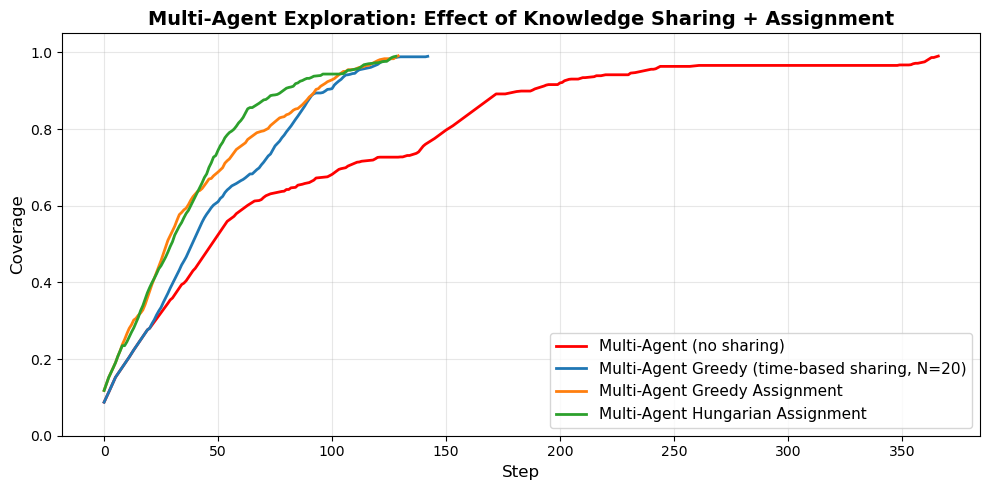

In [24]:
# Compare all the different multi-agent strategies 
fig, ax = plt.subplots(figsize=(10, 5))


ax.plot(multi_agent_step_history, multi_agent_coverage_history, 'r-', linewidth=2, label='Multi-Agent (no sharing)')

ax.plot(multi_agent_time_based_step_history, multi_agent_time_based_coverage_history, linewidth=2, label=f'Multi-Agent Greedy (time-based sharing, N={N})')

ax.plot(greedy_assignment_step_history, greedy_assignment_coverage_history, linewidth=2, label=f'Multi-Agent Greedy Assignment')

ax.plot(hungarian_assignment_step_history, hungarian_assignment_coverage_history, linewidth=2, label=f'Multi-Agent Hungarian Assignment')

ax.set_xlabel('Step', fontsize=12)
ax.set_ylabel('Coverage', fontsize=12)
ax.set_title('Multi-Agent Exploration: Effect of Knowledge Sharing + Assignment', fontsize=14, fontweight='bold')

ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 1.05])
plt.tight_layout()
plt.savefig("q5_multi_agent_sharing_comparison.png")
plt.show()




In some scenarios, you may observe the greedy assignment outperforming the hungarian assignment algorithm. Why might this be? Try running the algorithms on larger (e.g. more agents, bigger map) scenarios. What happens?

## Step 7: Parameter Tuning and Analysis


Let's explore how different parameters affect exploration performance.

### Key Parameters:
- **α (alpha)**: Weight for information gain
- **β (beta)**: Weight for path cost  
- **IG radius**: How far ahead to look for unknown cells
- **Replanning period**: How often to recompute targets

The utility function is:
$$
U(r_i, t_j) = \alpha \cdot \text{IG}(t_j) - \beta \cdot \text{Cost}(r_i, t_j)
$$

In [28]:
# Experiment with different alpha/beta ratios
def run_experiment(alpha, beta, num_robots=3, max_steps=300, seed=789):
    """Run one exploration experiment and return final coverage."""
    config = EnvConfig(
        width=35,
        height=35,
        num_robots=num_robots,
        max_steps=max_steps,
        sensor_radius=3,
        obstacle_prob=0.15,
        seed=seed
    )
    
    env = GridWorldEnv(config)
    obs = env.reset()
    
    heuristic_config = HeuristicConfig(
        alpha=alpha,
        beta=beta,
        ig_radius=4,
        replanning_period=10
    )
    policy = HeuristicFrontierPolicy(config=heuristic_config)
    policy.reset(obs)
    
    for step in range(max_steps):
        actions = policy.act(obs)
        result = env.step(actions)
        obs = env.observe()
        
        if result.done or result.coverage >= 0.95:
            break
    
    return result.coverage, step

# Test different parameter combinations
print("Testing different α/β ratios...\n")
param_results = []

#TODO: Define the parameter ranges -- feel free to modify
alpha_space = np.linspace(0.001, 2.0, 5)
beta_space = np.linspace(0.01, 1.0, 4)

for alpha in alpha_space:
    for beta in beta_space:
        coverage, steps = run_experiment(alpha, beta)
        param_results.append((alpha, beta, coverage, steps))
        print(f"α={alpha:.1f}, β={beta:.2f}: Coverage={coverage:.2%} in {steps} steps")

print("\n✓ Parameter sweep complete")

Testing different α/β ratios...

α=0.0, β=0.01: Coverage=95.18% in 107 steps
α=0.0, β=0.34: Coverage=95.35% in 101 steps
α=0.0, β=0.67: Coverage=95.35% in 101 steps
α=0.0, β=1.00: Coverage=95.35% in 101 steps
α=0.5, β=0.01: Coverage=95.02% in 213 steps
α=0.5, β=0.34: Coverage=95.27% in 137 steps
α=0.5, β=0.67: Coverage=95.10% in 110 steps
α=0.5, β=1.00: Coverage=95.18% in 105 steps
α=1.0, β=0.01: Coverage=95.02% in 213 steps
α=1.0, β=0.34: Coverage=95.02% in 158 steps
α=1.0, β=0.67: Coverage=95.27% in 137 steps
α=1.0, β=1.00: Coverage=95.18% in 101 steps
α=1.5, β=0.01: Coverage=95.02% in 213 steps
α=1.5, β=0.34: Coverage=95.02% in 188 steps
α=1.5, β=0.67: Coverage=95.10% in 169 steps
α=1.5, β=1.00: Coverage=95.02% in 170 steps
α=2.0, β=0.01: Coverage=95.02% in 213 steps
α=2.0, β=0.34: Coverage=95.27% in 199 steps
α=2.0, β=0.67: Coverage=95.02% in 158 steps
α=2.0, β=1.00: Coverage=95.02% in 179 steps

✓ Parameter sweep complete


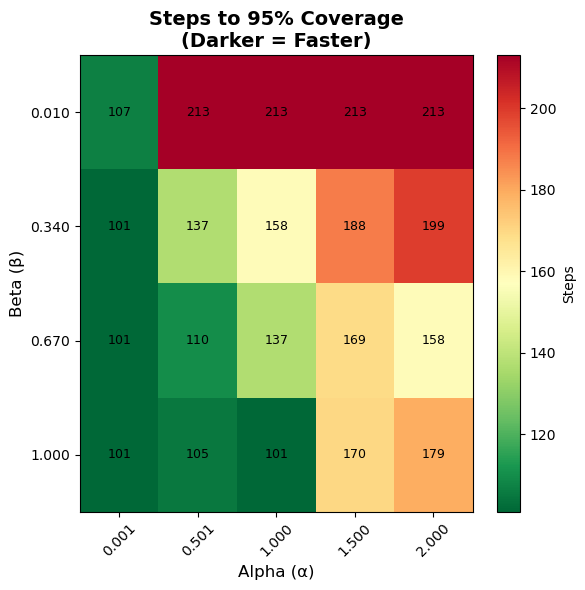

In [29]:
# Visualize parameter sweep results as heatmap
fig, axes = plt.subplots(1, 1, figsize=(6, 6))

# Prepare data for heatmap
alphas_unique = sorted(list(set([r[0] for r in param_results])))
betas_unique = sorted(list(set([r[1] for r in param_results])))

# Create matrices for steps and coverage
steps_matrix = np.zeros((len(betas_unique), len(alphas_unique)))
coverage_matrix = np.zeros((len(betas_unique), len(alphas_unique)))

for alpha, beta, coverage, steps in param_results:
    i = betas_unique.index(beta)
    j = alphas_unique.index(alpha)
    steps_matrix[i, j] = steps
    coverage_matrix[i, j] = coverage

# Plot 1: Steps to completion (lower is better)
im1 = axes.imshow(steps_matrix, cmap='RdYlGn_r', aspect='auto')
axes.set_xlabel('Alpha (α)', fontsize=12)
axes.set_ylabel('Beta (β)', fontsize=12)
axes.set_title('Steps to 95% Coverage\n(Darker = Faster)', fontsize=14, fontweight='bold')
axes.set_xticks(range(len(alphas_unique)))
axes.set_yticks(range(len(betas_unique)))
axes.set_xticklabels([f'{a:.3f}' for a in alphas_unique], rotation=45)
axes.set_yticklabels([f'{b:.3f}' for b in betas_unique])

# Add text annotations
for i in range(len(betas_unique)):
    for j in range(len(alphas_unique)):
        text = axes.text(j, i, f'{int(steps_matrix[i, j])}',
                           ha="center", va="center", color="black", fontsize=9)

plt.colorbar(im1, ax=axes, label='Steps')

plt.tight_layout()
plt.savefig("q6_parameter_sweep_heatmap.png")
plt.show()

In [30]:
# Find best parameters (minimum steps to reach high coverage)
best_params = min(param_results, key=lambda x: x[3])  # Minimize steps
print(f"\n🏆 Best parameters (fastest exploration):")
print(f"   α = {best_params[0]:.3f}, β = {best_params[1]:.3f}")
print(f"   Steps to completion: {best_params[3]}")
print(f"   Final coverage: {best_params[2]:.2%}")



🏆 Best parameters (fastest exploration):
   α = 0.001, β = 0.340
   Steps to completion: 101
   Final coverage: 95.35%


## Bonus: Create Exploration GIF

Let's create an animated GIF showing the multi-agent exploration in action!

### Customize Your GIF

You can adjust the parameters to create different visualizations:

```python
# Faster animation (shorter duration per frame)
create_exploration_gif(gif_config, gif_policy_config, 
                       output_path="fast_exploration.gif",
                       duration=50)

# Higher quality (more frames, slower capture)
create_exploration_gif(gif_config, gif_policy_config,
                       output_path="smooth_exploration.gif", 
                       frame_interval=2,
                       figsize=(12, 12))

# Without frontiers (cleaner view)
create_exploration_gif(gif_config, gif_policy_config,
                       output_path="clean_exploration.gif",
                       show_frontiers=False)

# Larger environment
large_config = EnvConfig(width=50, height=50, num_robots=5, 
                         max_steps=400, sensor_radius=4, 
                         obstacle_prob=0.15, seed=42)
create_exploration_gif(large_config, gif_policy_config,
                       output_path="large_exploration.gif",
                       frame_interval=10)
```

In [32]:
# Create a GIF of multi-agent exploration
gif_config = EnvConfig(
    width=50,
    height=50,
    num_robots=4,
    max_steps=300,
    sensor_radius=3,
    obstacle_prob=0.15,
    seed=999
)

# TODO: Apply optimal alpha & beta from paramter tuning!
gif_policy_config = HeuristicConfig(
    alpha=0.001,
    beta=0.34,
    ig_radius=4,
    replanning_period=1,
    assignment_method='greedy'
)

# Generate the GIF (this may take 30-60 seconds)
gif_path = create_exploration_gif(
    config=gif_config,
    policy_config=gif_policy_config,
    output_path="multi_agent_exploration.gif",
    frame_interval=1,  # Capture every 1 steps
    duration=150,      # 150ms per frame
    show_frontiers=True,
    figsize=(8, 8)
)

print(f"\n🎬 GIF created: {gif_path}")

Generating exploration GIF with 4 robots...
Capturing frames every 1 steps
  Step   1: Coverage = 8.96%, Frames captured: 2
  Step   2: Coverage = 10.08%, Frames captured: 3
  Step   3: Coverage = 10.92%, Frames captured: 4
  Step   4: Coverage = 11.76%, Frames captured: 5
  Step   5: Coverage = 12.76%, Frames captured: 6
  Step   6: Coverage = 13.56%, Frames captured: 7
  Step   7: Coverage = 14.24%, Frames captured: 8
  Step   8: Coverage = 15.20%, Frames captured: 9
  Step   9: Coverage = 16.04%, Frames captured: 10
  Step  10: Coverage = 16.60%, Frames captured: 11
  Step  11: Coverage = 17.44%, Frames captured: 12
  Step  12: Coverage = 18.52%, Frames captured: 13
  Step  13: Coverage = 19.36%, Frames captured: 14
  Step  14: Coverage = 19.76%, Frames captured: 15
  Step  15: Coverage = 20.32%, Frames captured: 16
  Step  16: Coverage = 20.88%, Frames captured: 17
  Step  17: Coverage = 21.44%, Frames captured: 18
  Step  18: Coverage = 22.04%, Frames captured: 19
  Step  19: Cove